            date    close
0     22/01/1999   0.0313
1     25/01/1999   0.0313
2     26/01/1999   0.0315
3     27/01/1999   0.0314
4     28/01/1999   0.0314
...          ...      ...
6996  17/11/2025  19.7656
6997  18/11/2025  19.6469
6998  19/11/2025  19.7319
6999  20/11/2025  19.6680
7000  21/11/2025  19.6532

[7001 rows x 2 columns]


<Axes: title={'center': 'NVDIA Closing Price'}>

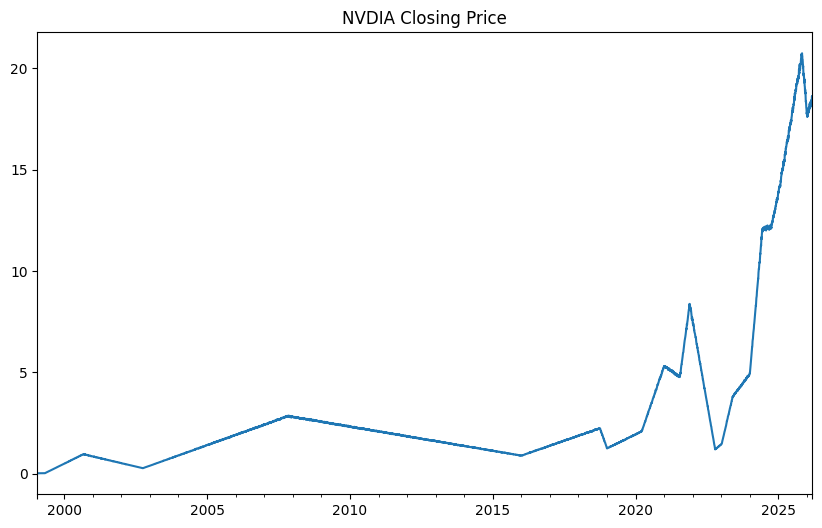

In [85]:
import pandas as pd
import matplotlib as plt

data =  pd.read_csv(r"C:\Users\Mareko\OneDrive\Documents\Python Statistika\DataSets\nvidia_stock_data_1999_2026.csv",)

data = data[['date','close']]  # Kita fokus pada harga penutupan
print(data.head(7001))

# Set frekuensi pada indeks
data.index = pd.date_range(start='1999-01-22', periods=len(data), freq='B')  # B untuk hari kerja

# Visualisasi data harga penutupan
data['close'].plot(figsize=(10,6), title='NVDIA Closing Price')


In [86]:
# Cek apakah ada missing value
missing_values = data.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

Jumlah missing values per kolom:
date     0
close    0
dtype: int64


In [87]:
# Cek apakah ada nilai NaN
nan_values = data.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)

Jumlah nilai NaN per kolom:
date     0
close    0
dtype: int64


In [88]:
from statsmodels.tsa.stattools import adfuller

# Uji ADF
result = adfuller(data['close'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Cek Hipotesis
if result[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


ADF Statistic: 1.125550
p-value: 0.995429
Data tidak stasioner, lakukan differencing.


p-value after differencing: 0.000000
Data stasioner, lanjutkan analisis.


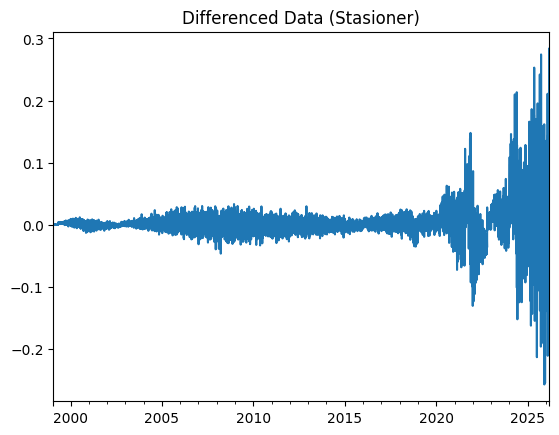

In [89]:
# Lakukan Differencing jika data tidak stasioner
data_diff = data['close'].diff().dropna()
data_diff.plot(title="Differenced Data (Stasioner)")

# Uji ADF lagi setelah differencing
result_diff = adfuller(data_diff)
print('p-value after differencing: %f' % result_diff[1])

# Cek Hipotesis
if result_diff[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")

In [90]:
# Cek apakah ada missing value
missing_values = data_diff.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

# Cek apakah ada nilai NaN
nan_values = data_diff.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)

Jumlah missing values per kolom:
0
Jumlah nilai NaN per kolom:
0


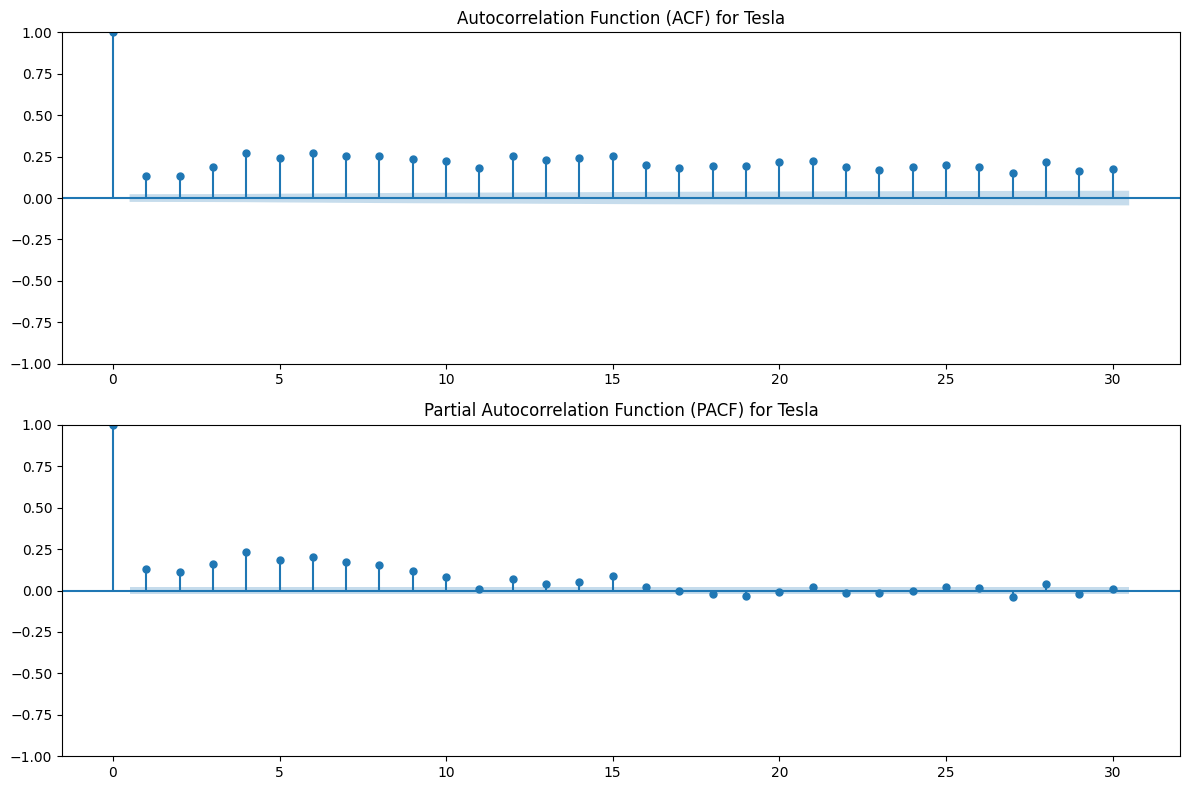

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF untuk menentukan q
plot_acf(data_diff, lags=30, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) for NVDIA')

# PACF untuk menentukan p
plot_pacf(data_diff, lags=30, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) for NVDIA')

plt.tight_layout()
plt.show()

In [92]:
from statsmodels.tsa.arima.model import ARIMA

# Membangun model ARIMA (p=1, d=1, q=1) berdasarkan plot ACF dan PACF
model = ARIMA(data['close'], order=(1,1,1))
model_fit = model.fit()

# Tampilkan ringkasan model
print(model_fit.summary())

c:\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 7079
Model:                 ARIMA(1, 1, 1)   Log Likelihood               16246.504
Date:                Mon, 30 Mar 2026   AIC                         -32487.009
Time:                        14:53:40   BIC                         -32466.414
Sample:                    01-22-1999   HQIC                        -32479.916
                         - 03-11-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9915      0.001   1245.801      0.000       0.990       0.993
ma.L1         -0.9295      0.002   -500.307      0.000      -0.933      -0.926
sigma2         0.0006   2.64e-06    224.818      0.0

In [93]:
# Jumlah langkah yang ingin diramalkan
n_steps = 20

# Lakukan peramalan
forecast = model_fit.forecast(steps=n_steps)

# Tampilkan hasil peramalan
print(forecast)

2026-03-12    18.617957
2026-03-13    18.635761
2026-03-16    18.653413
2026-03-17    18.670914
2026-03-18    18.688265
2026-03-19    18.705469
2026-03-20    18.722526
2026-03-23    18.739437
2026-03-24    18.756203
2026-03-25    18.772827
2026-03-26    18.789308
2026-03-27    18.805649
2026-03-30    18.821851
2026-03-31    18.837914
2026-04-01    18.853839
2026-04-02    18.869629
2026-04-03    18.885285
2026-04-06    18.900806
2026-04-07    18.916195
2026-04-08    18.931453
Freq: B, Name: predicted_mean, dtype: float64


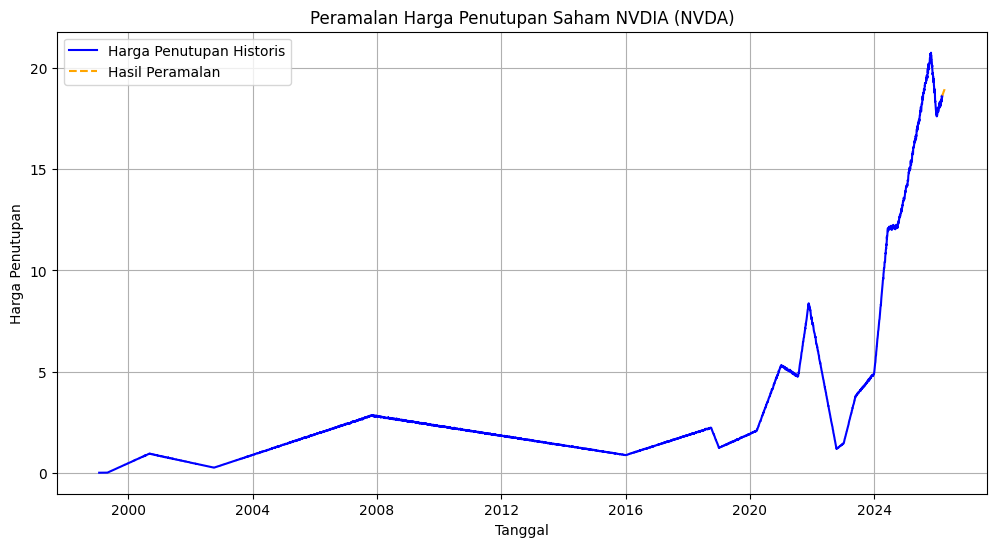

In [94]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['close'], label='Harga Penutupan Historis', color='blue')

# Membuat indeks untuk peramalan
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=n_steps, freq='B')

# Plot hasil peramalan
plt.plot(forecast_index, forecast, label='Hasil Peramalan', color='orange', linestyle='--')

# Tambahkan elemen visual lainnya
plt.title('Peramalan Harga Penutupan Saham NVDIA (NVDA)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.grid()
plt.show()